# **Exploring the NYC Airbnb Market**

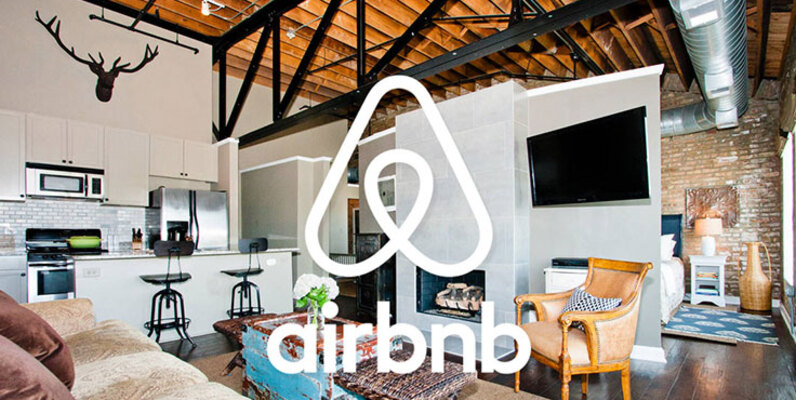

## **Problem Statement**
The goal of this project is to conduct an in-depth analysis of the NYC market using publicly available data. By exploring the dataset, I aim to uncover trends, patterns, and insights that can inform business decisions for hosts, property managers, and invetors. The project will focus on data cleaning, exploratory data analysis (EDA), visualization, and predictive modeling to answer key business questions.

## **Business Questions**

1. What are the most popular neighborhoods in NYC for Airbnb rentals?
2. How do prices vary accross different neighborhoods and room types?
3. What factors influence the pricing of Airbnb listings?
4. Can we predict the price of an Airbnb listings based on its attributes?

## **Data Sources**
The dataset used for this project is sourced from http://insideairbnb.com/get-the-data.html, which provides detailed information about Airbnb listing in NYC.

The dataset includes variable such as listing ID, host ID, neighborhood, room type, price, reviews, and more.

## **Step 1: Data Loading and Understanding**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

In [2]:
# Load the dataset
df = pd.read_csv('listings.csv')
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,621960198566758900,https://www.airbnb.com/rooms/621960198566758900,20250302010353,2025-03-02,city scrape,The Historic Jesse Buel Farmhouse w/ Heated Pool,4800ft of living space and an epic backyard ma...,"Walkable, Safe and quiet",https://a0.muscache.com/pictures/dd1a2e33-d50b...,382970529,...,5.00,4.87,5.00,NaN,f,12,2,10,0,0.47
1,932642358896439621,https://www.airbnb.com/rooms/932642358896439621,20250302010353,2025-03-02,city scrape,Stylish top floor apt w/parking,The whole group will enjoy easy access to ever...,Pine Hills Neighborhood in Albany NY is full o...,https://a0.muscache.com/pictures/prohost-api/H...,232967878,...,4.84,4.65,4.76,NaN,f,23,23,0,0,1.88
2,53567589,https://www.airbnb.com/rooms/53567589,20250302010353,2025-03-02,city scrape,Private Garden Apt in Downtown Albany|Pets All...,Discover Lark Street - A Hip Albany Neighborho...,If you visit Albany’s Capital Region without s...,https://a0.muscache.com/pictures/2e5b6926-a177...,433096110,...,4.96,4.79,4.86,NaN,f,4,4,0,0,6.40
3,20671966,https://www.airbnb.com/rooms/20671966,20250302010353,2025-03-02,city scrape,The Metropolitan,This full apartment is located on the 3rd floo...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,98744672,...,4.98,4.93,4.87,NaN,f,8,2,6,0,0.51
4,24606880,https://www.airbnb.com/rooms/24606880,20250302010353,2025-03-02,city scrape,The Western Suite,"Located in a huge Victorian, this beautiful su...",NaN,https://a0.muscache.com/pictures/e8183a7b-a392...,98744672,...,4.96,4.96,4.88,NaN,f,8,2,6,0,0.62


In [3]:
def explore_data(df):
    # Display the shape of the dataset
    print("\nShape of the dataset:")
    print(df.shape)
    
    # Display the data types of each column
    print("\nInformation about each column:")
    print(df.info())
    
    # Display summary statistics for numerical columns
    print("\nSummary statistics:")
    display(df.describe())
    
    # Display the number of missing values in each column
    print("\nMissing values in each column:")
    print(df.isnull().sum())
    
explore_data(df)


Shape of the dataset:
(424, 79)

Information about each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            424 non-null    int64  
 1   listing_url                                   424 non-null    object 
 2   scrape_id                                     424 non-null    int64  
 3   last_scraped                                  424 non-null    object 
 4   source                                        424 non-null    object 
 5   name                                          424 non-null    object 
 6   description                                   413 non-null    object 
 7   neighborhood_overview                         206 non-null    object 
 8   picture_url                                   424 non-null    object 
 9   

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,4.240000e+02,4.240000e+02,4.240000e+02,423.000000,423.000000,0.0,424.000000,424.000000,424.000000,374.000000,...,366.000000,366.000000,366.000000,366.000000,0.0,424.000000,424.000000,424.000000,424.0,366.000000
mean,6.907163e+17,2.025030e+13,2.386313e+08,29.472813,49.392435,NaN,42.657833,-73.776658,3.476415,1.231283,...,4.855437,4.873525,4.688880,4.730792,NaN,6.174528,4.471698,1.702830,0.0,1.987077
std,5.017984e+17,0.000000e+00,1.959192e+08,149.759455,293.856055,NaN,0.009929,0.019287,2.461891,0.673600,...,0.280059,0.245808,0.347114,0.389397,NaN,6.372051,6.069663,3.507694,0.0,1.981654
min,2.992450e+06,2.025030e+13,6.576000e+04,1.000000,1.000000,NaN,42.630660,-73.876490,1.000000,0.000000,...,2.000000,3.000000,3.000000,1.000000,NaN,1.000000,0.000000,0.000000,0.0,0.040000
25%,5.196373e+07,2.025030e+13,4.762598e+07,2.000000,2.000000,NaN,42.652047,-73.789767,2.000000,1.000000,...,4.832500,4.860000,4.542500,4.670000,NaN,1.000000,1.000000,0.000000,0.0,0.490000
50%,8.415244e+17,2.025030e+13,1.891330e+08,4.000000,6.000000,NaN,42.656976,-73.773065,3.000000,1.000000,...,4.940000,4.960000,4.810000,4.830000,NaN,3.000000,2.000000,0.000000,0.0,1.350000
75%,1.128346e+18,2.025030e+13,3.976121e+08,12.000000,15.000000,NaN,42.663191,-73.763191,4.000000,1.000000,...,5.000000,5.000000,4.940000,4.947500,NaN,9.000000,5.000000,1.000000,0.0,2.942500
max,1.365429e+18,2.025030e+13,6.773730e+08,1202.000000,2457.000000,NaN,42.714900,-73.738250,16.000000,7.000000,...,5.000000,5.000000,5.000000,5.000000,NaN,23.000000,23.000000,13.000000,0.0,10.980000



Missing values in each column:
id                                               0
listing_url                                      0
scrape_id                                        0
last_scraped                                     0
source                                           0
                                                ..
calculated_host_listings_count                   0
calculated_host_listings_count_entire_homes      0
calculated_host_listings_count_private_rooms     0
calculated_host_listings_count_shared_rooms      0
reviews_per_month                               58
Length: 79, dtype: int64


## **Data Wrangling**

In [4]:
# Checking the columns
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [5]:
selected_cols = [
    'id', 'name', 'neighbourhood_cleansed', 'room_type', 'price',
    'minimum_nights', 'number_of_reviews', 'review_scores_rating',
    'reviews_per_month', 'availability_365', 'calculated_host_listings_count',
    'latitude', 'longitude'
]

df_selected = df[selected_cols]
df_selected.head()

,id,name,neighbourhood_cleansed,room_type,price,minimum_nights,number_of_reviews,review_scores_rating,reviews_per_month,availability_365,calculated_host_listings_count,latitude,longitude
0,621960198566758900,The Historic Jesse Buel Farmhouse w/ Heated Pool,FOURTEENTH WARD,Entire home/apt,$882.00,1,15,5.00,0.47,330,12,42.66762,-73.79919
1,932642358896439621,Stylish top floor apt w/parking,THIRTEENTH WARD,Entire home/apt,$106.00,1,37,4.70,1.88,86,23,42.67224,-73.79301
2,53567589,Private Garden Apt in Downtown Albany|Pets All...,SIXTH WARD,Entire home/apt,$99.00,1,251,4.89,6.40,341,4,42.65204,-73.76655
3,20671966,The Metropolitan,NINTH WARD,Entire home/apt,$58.00,2,46,4.91,0.51,248,8,42.65532,-73.78244
4,24606880,The Western Suite,NINTH WARD,Private room,$50.00,2,48,4.94,0.62,340,8,42.65431,-73.78178


In [6]:
# Shape of the dataset
df_selected.shape

(424, 13)

review_scores_rating    58
reviews_per_month       58
price                   50
dtype: int64

review_scores_rating    13.68
reviews_per_month       13.68
price                   11.79
dtype: float64

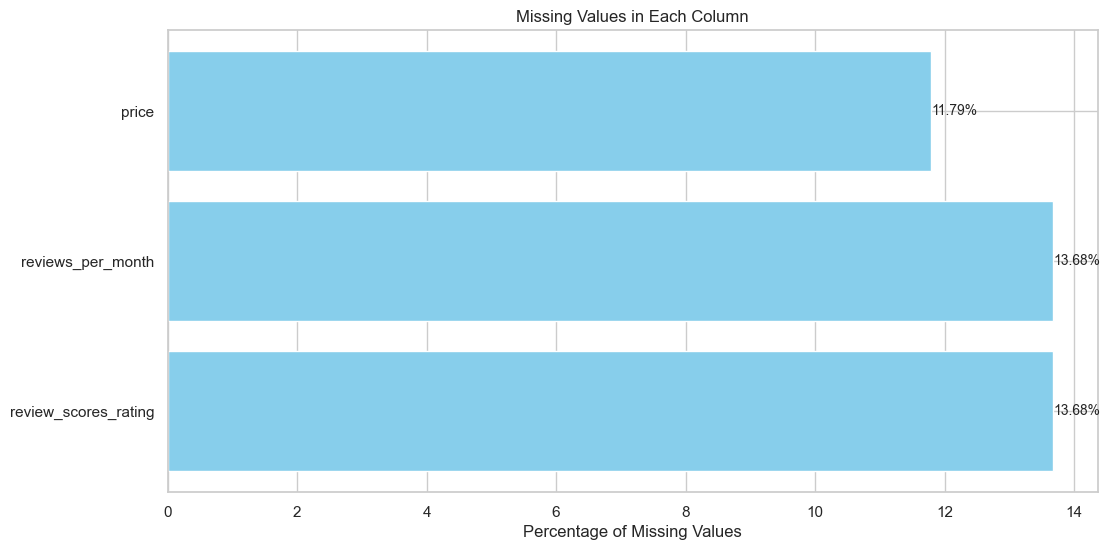

In [7]:
def check_missing_values(df):
    # Check for missing values in the dataset
    missing_values = df.isnull().sum()
    missing_values = missing_values[missing_values > 0]
    return missing_values

missing_values = check_missing_values(df_selected)
missing_values.sort_values(ascending=False, inplace=True)
missing_values_percentage = round((missing_values / len(df_selected)) * 100,2)
display(missing_values, missing_values_percentage)

# Visualize missing values
plt.figure(figsize=(12, 6))
plt.barh(missing_values.index, missing_values_percentage, color='skyblue')
for index, value in enumerate(missing_values_percentage):
    plt.text(value, index, str(value) + '%', va='center', fontsize=10)
plt.xlabel('Percentage of Missing Values')
plt.title('Missing Values in Each Column')
plt.show()

In [8]:
# Remove '$' and ',' in price → convert to numeric
df_selected['price'] = df_selected['price'].replace({'\$':'', ',':''}, regex=True).astype(float)

# Drop rows where price is missing
df_selected = df_selected.dropna(subset=['price'])

# Impute missing review_scores_rating and reviews_per_month with median
df_selected['review_scores_rating'].fillna(df_selected['review_scores_rating'].median(), inplace=True)
df_selected['reviews_per_month'].fillna(df_selected['reviews_per_month'].median(), inplace=True)

# Confirm no more missing
print("\nMissing after cleaning:\n", df_selected.isnull().sum())


Missing after cleaning:
 id                                0
name                              0
neighbourhood_cleansed            0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
review_scores_rating              0
reviews_per_month                 0
availability_365                  0
calculated_host_listings_count    0
latitude                          0
longitude                         0
dtype: int64


## **Exploratory Data Analysis**

### *Popular neighborhoods*

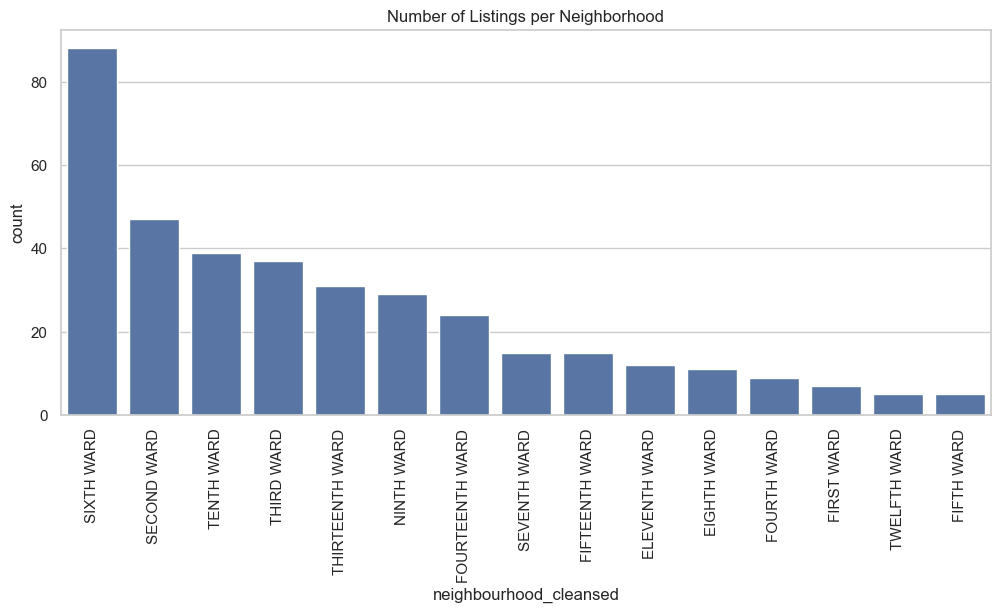

In [9]:
# Popular neighborhoods
plt.figure(figsize=(12,5))
sns.countplot(data=df_selected, x='neighbourhood_cleansed', order=df_selected['neighbourhood_cleansed'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Number of Listings per Neighborhood")
plt.show()

### *Price distribution by neighborhood*

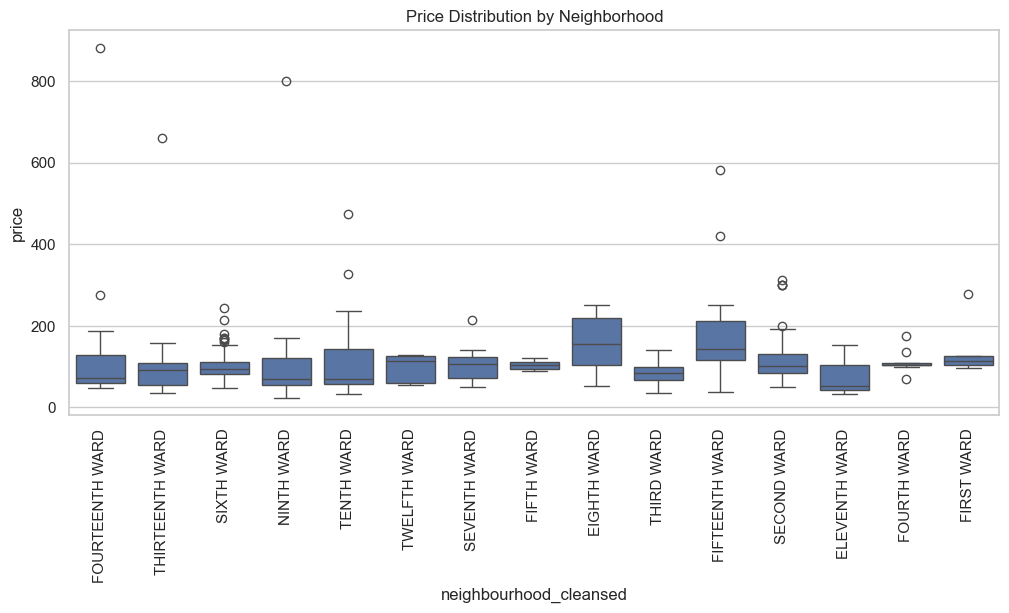

In [10]:
# Price distribution by neighborhood
plt.figure(figsize=(12,5))
sns.boxplot(data=df_selected, x='neighbourhood_cleansed', y='price')
plt.xticks(rotation=90)
plt.title("Price Distribution by Neighborhood")
plt.show()

### *Price by room type*

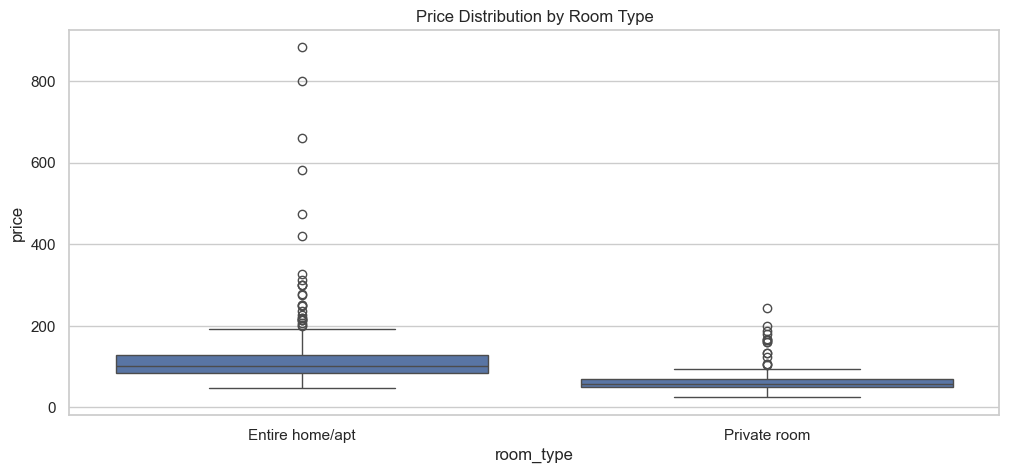

In [11]:
# Price by room type
plt.figure(figsize=(12,5))
sns.boxplot(data=df_selected, x='room_type', y='price')
plt.title("Price Distribution by Room Type")
plt.show()

### *Correlation Matrix*

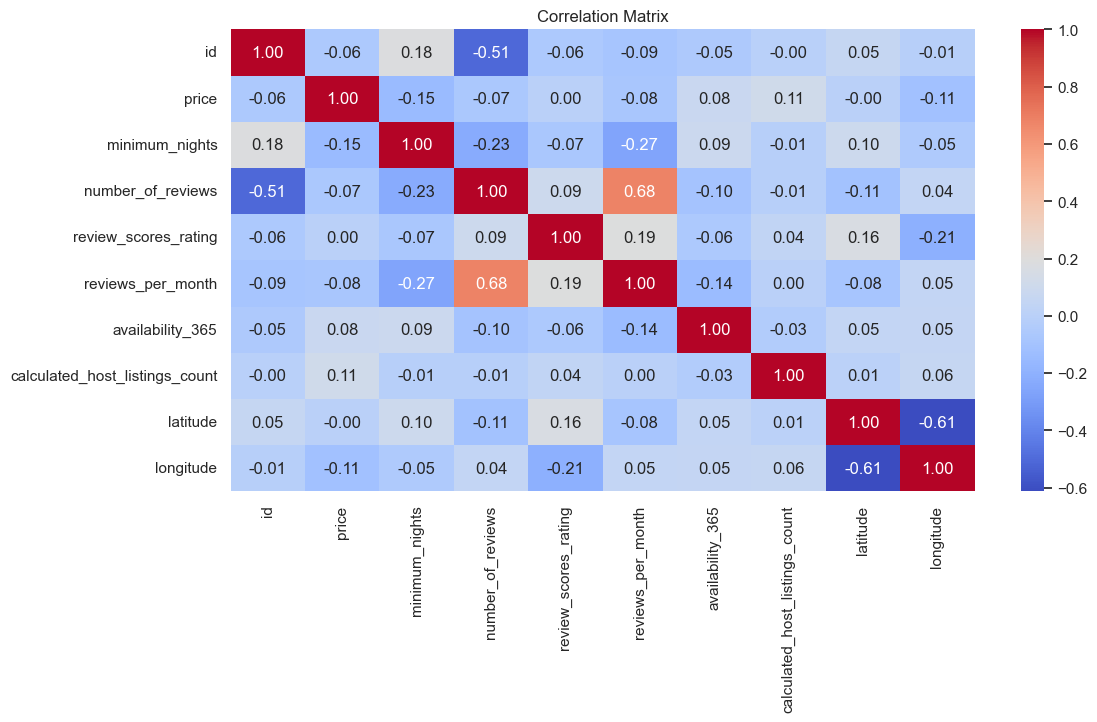

In [12]:
# Correlation heatmap
plt.figure(figsize=(12,6))
sns.heatmap(df_selected.select_dtypes(exclude='object').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## **Data Preprocessing**

In [13]:
# Encode categorical columns
le_neighbourhood = LabelEncoder()
df_selected['neighbourhood_encoded'] = le_neighbourhood.fit_transform(df_selected['neighbourhood_cleansed'])

le_roomtype = LabelEncoder()
df_selected['room_type_encoded'] = le_roomtype.fit_transform(df_selected['room_type'])

df_selected.head(3)

,id,name,neighbourhood_cleansed,room_type,price,minimum_nights,number_of_reviews,review_scores_rating,reviews_per_month,availability_365,calculated_host_listings_count,latitude,longitude,neighbourhood_encoded,room_type_encoded
0,621960198566758900,The Historic Jesse Buel Farmhouse w/ Heated Pool,FOURTEENTH WARD,Entire home/apt,882.0,1,15,5.00,0.47,330,12,42.66762,-73.79919,5,0
1,932642358896439621,Stylish top floor apt w/parking,THIRTEENTH WARD,Entire home/apt,106.0,1,37,4.70,1.88,86,23,42.67224,-73.79301,13,0
2,53567589,Private Garden Apt in Downtown Albany|Pets All...,SIXTH WARD,Entire home/apt,99.0,1,251,4.89,6.40,341,4,42.65204,-73.76655,10,0


In [14]:
# Select features & target
features = ['neighbourhood_encoded', 'room_type_encoded', 'minimum_nights',
            'number_of_reviews', 'review_scores_rating', 'reviews_per_month',
            'availability_365', 'calculated_host_listings_count']

X = df_selected[features]
y = df_selected['price']

# Optionally scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_feature = pd.DataFrame(X_scaled, columns=features)
X_feature.head(3)


,neighbourhood_encoded,room_type_encoded,minimum_nights,number_of_reviews,review_scores_rating,reviews_per_month,availability_365,calculated_host_listings_count
0,-1.024383,-0.608246,-0.489245,-0.436415,0.674020,-0.805447,0.763235,0.925366
1,1.281827,-0.608246,-0.489245,-0.239873,-0.228750,-0.068108,-1.450961,2.680532
2,0.416998,-0.608246,-0.489245,1.671944,0.343004,2.295563,0.863055,-0.351119


In [15]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_feature, y, test_size=0.2, random_state=42)
display(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(299, 8)

(75, 8)

(299,)

(75,)

## **Machine Learning**

### *Linear Regression*

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_pred_lr[:5]

array([132.13055564,  55.2450865 ,  82.42427603, 106.7679085 ,
        29.11740622])

RMSE: 98.28
MAE: 48.85
R^2: 0.10


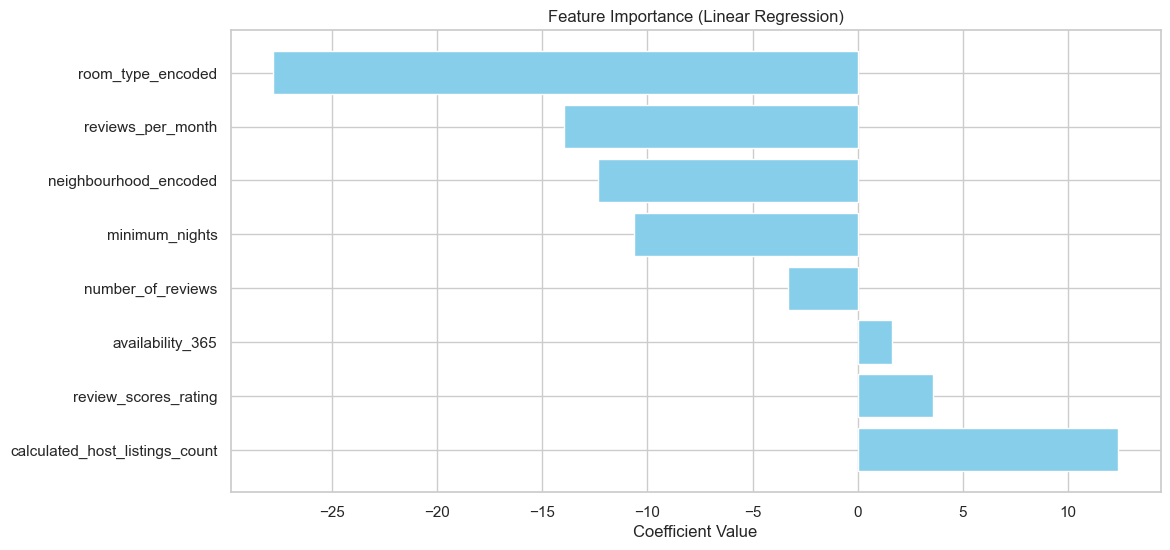

In [17]:
# Analyze the model performance
def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R^2: {r2:.2f}")
evaluate_model(y_test, y_pred_lr)


# Feature importance
importance = lr.coef_
importance_df = pd.DataFrame(importance, index=X_feature.columns, columns=['Coefficient'])
importance_df = importance_df.sort_values(by='Coefficient', ascending=False)
plt.figure(figsize=(12, 6))
plt.barh(importance_df.index, importance_df['Coefficient'], color='skyblue')
plt.title("Feature Importance (Linear Regression)")
plt.xlabel("Coefficient Value")
plt.show()

### *Random Forest*

RMSE: 91.92
MAE: 46.80
R^2: 0.21


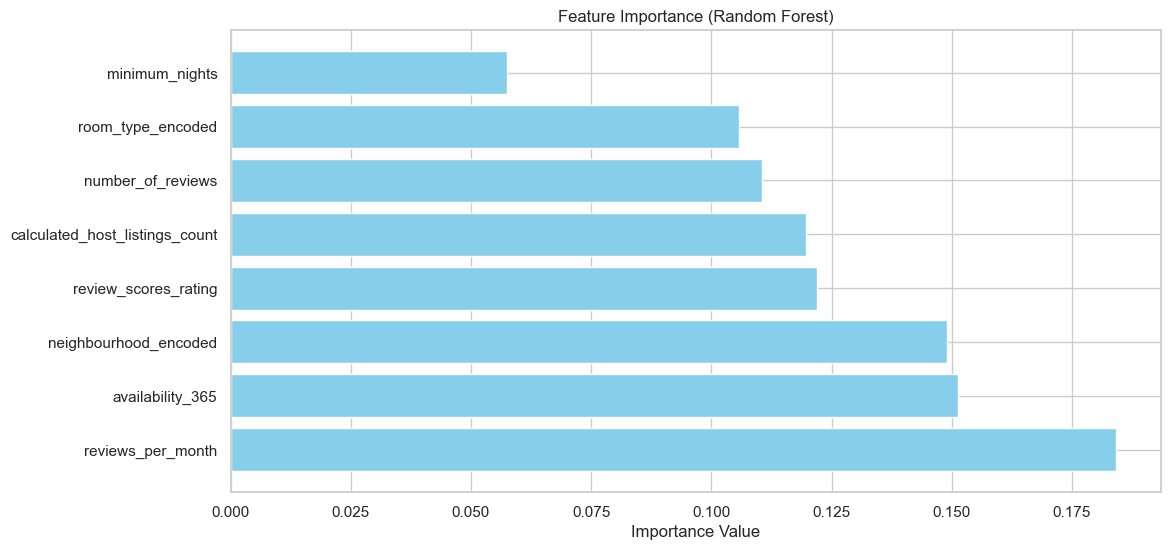

In [18]:
# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
evaluate_model(y_test, y_pred_rf)


# Feature importance for Random Forest
importance_rf = rf.feature_importances_
importance_rf_df = pd.DataFrame(importance_rf, index=X_feature.columns, columns=['Importance'])
importance_rf_df = importance_rf_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(12, 6))
plt.barh(importance_rf_df.index, importance_rf_df['Importance'], color='skyblue')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Value")
plt.show()

### *Using LazyPredict*

Using lazypredict will automatically run multiple machine learning models and compare their performance in a single table.

In [20]:
from lazypredict.Supervised import LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 316
[LightGBM] [Info] Number of data points in the train set: 299, number of used features: 8
[LightGBM] [Info] Start training from score 108.140468
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [22]:
# Display model comparison
pd.set_option('display.width', 1000)
print(models)

                               Adjusted R-Squared  R-Squared   RMSE  Time Taken
Model                                                                          
RandomForestRegressor                        0.13       0.22  91.54        0.92
KNeighborsRegressor                          0.12       0.22  91.77        0.05
ExtraTreesRegressor                          0.09       0.19  93.30        1.56
LGBMRegressor                                0.09       0.19  93.54        0.21
BaggingRegressor                             0.08       0.18  93.91        1.00
HistGradientBoostingRegressor                0.07       0.17  94.70        0.67
PoissonRegressor                             0.02       0.12  97.14        0.04
RidgeCV                                     -0.01       0.10  98.25        0.07
ElasticNetCV                                -0.01       0.10  98.26        1.13
BayesianRidge                               -0.01       0.10  98.27        0.20
Ridge                                   

Observation:

- All models have low R² (highest is 0.22) → means only 22% of price variability is explained by the features.
- RMSE around 91–154 → high error because the price range is not wide.
- Models didn’t perform very well → underfitting likely.

 Interpretation:
- This means the current features are not strong enough to predict price accurately.
- The model is missing important predictors or the relationship is too complex for simple features.